## Dataframe Loading and Basic Cleaning

In [2]:
import pandas as pd

# Load data as Dataframe

games_df = pd.read_csv('Data/Video_Games_Sales_Cleaned.csv')

# View 5 rows of data to understand columns

games_df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,release_year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0


In [3]:
# Check for duplicates

print(games_df.duplicated().sum())

# 4 duplicate rows found, lets drop them

games_df = games_df.drop_duplicates()

4


In [4]:
# Dataframe info

games_df.info()

<class 'pandas.DataFrame'>
Index: 18828 entries, 0 to 18831
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         18828 non-null  str    
 1   console       18828 non-null  str    
 2   genre         18828 non-null  str    
 3   publisher     18828 non-null  str    
 4   developer     18828 non-null  str    
 5   critic_score  18828 non-null  float64
 6   total_sales   18828 non-null  float64
 7   release_year  18828 non-null  float64
dtypes: float64(3), str(5)
memory usage: 1.3 MB


## Data Exploration and Graphing

Lets start by showing the distribution of genres, as well as graphing average sales numbers of different groups/categories to get insight into how genre classification may develop as weights in our training

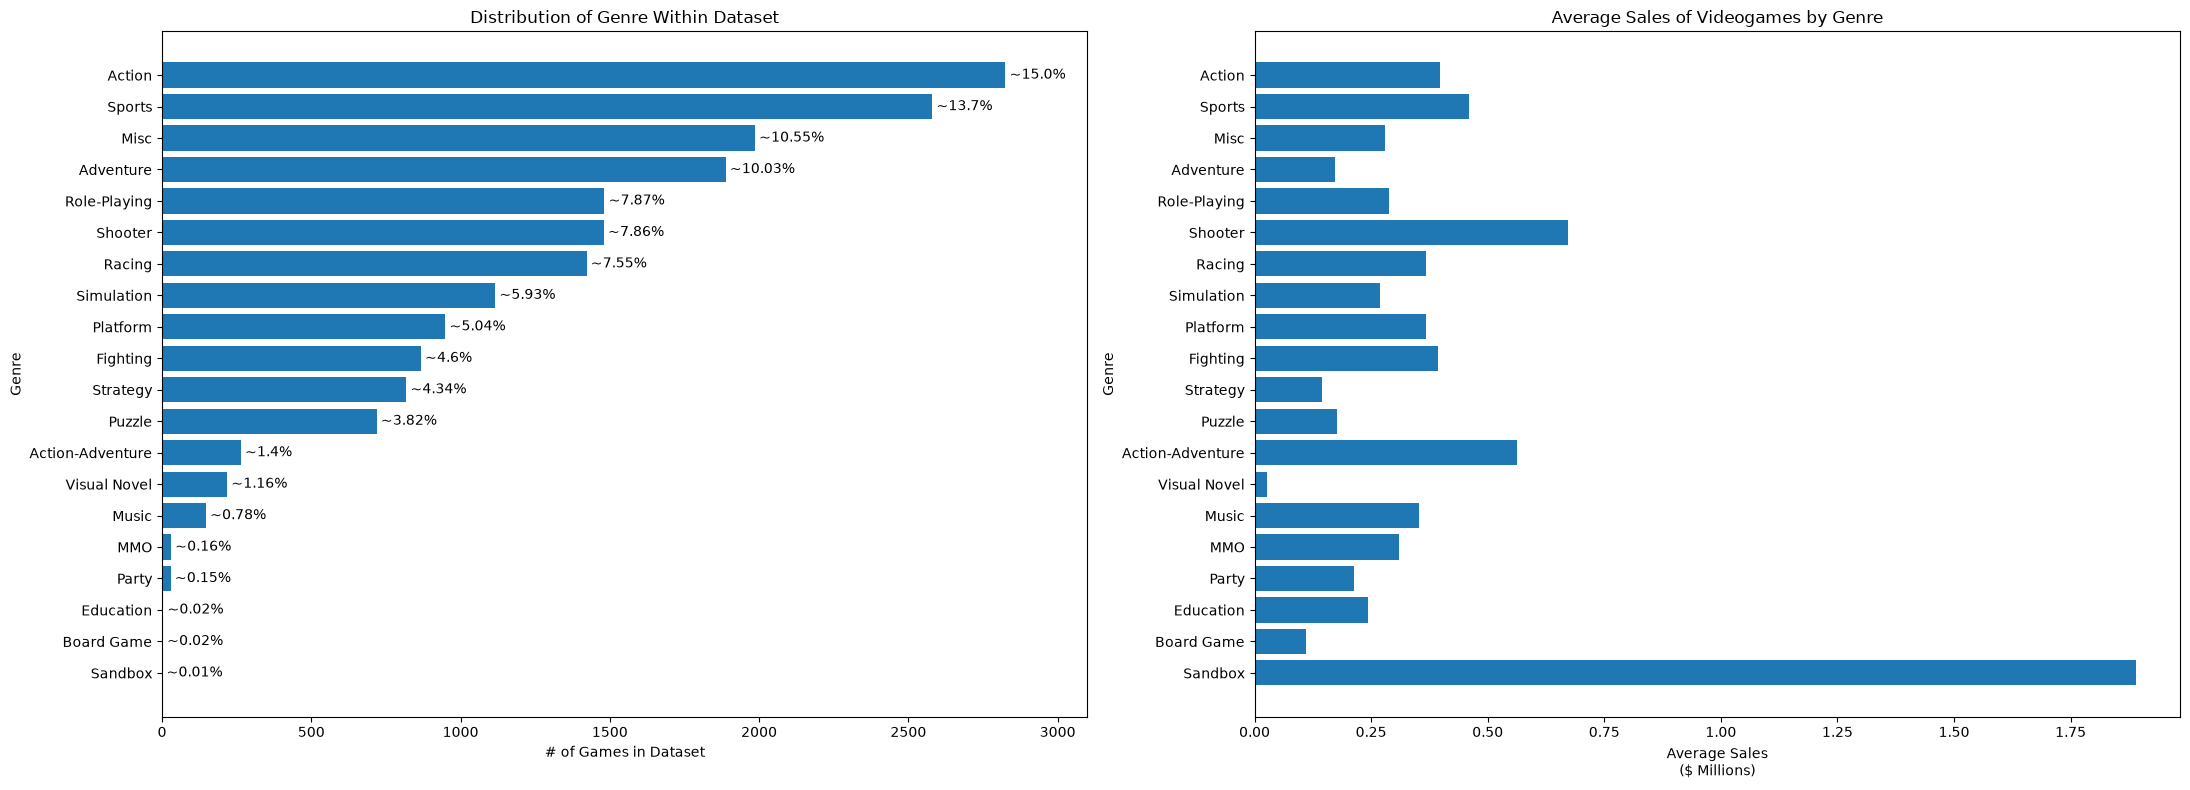

In [ ]:
import matplotlib.pyplot as plt

def plot_genre_statistics(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(1, 2, figsize=(22, 8))


    # Plot statistical distribution of genres

    values = df['genre'].value_counts(ascending=True)
    bar_labels = [f'~{round(100 * values.loc[x] / values.sum(), 2)}%' for x in values.index]
        
    bar = ax[0].barh(values.index, values)
    ax[0].set_title('Distribution of Genre Within Dataset')
    ax[0].set_ylabel('Genre')
    ax[0].set_xlabel('# of Games in Dataset')
    ax[0].bar_label(bar, bar_labels, padding=3)
    ax[0].set_xlim(right=3100)


    # Plot average sales in $ millions of each genre

    y = []

    for genre in values.index:
        genre_series = df.loc[df['genre'] == genre]['total_sales']
        y.append(genre_series.mean())

    ax[1].barh(values.index, y)
    ax[1].set_title('Average Sales of Videogames by Genre')
    ax[1].set_ylabel('Genre')
    ax[1].set_xlabel('Average Sales\n($ Millions)')


    plt.tight_layout()
    plt.show()

plot_genre_statistics(games_df)